# Setup

Load PyDPEET and set logging style to "Error" to prevent log spamming.

In [1]:
import pydpeet as eet

eet.set_logging_style("ERROR")

In [2]:
dfs = eet.read(config="neware_8_0_0_516", input_path="../../../res/raw")

df_merged = eet.merge_into_series(dfs)
# df_merged.head()

In [3]:
df_segments = eet.add_primitive_segments(df_merged)

In [4]:
# from importlib import reload
# reload(eet)


config = eet.lgm50lt_nmc_4800
config.voltage_intervall = 0.01
df_merged = eet.add_soc(df_merged, df_segments, standard_method=eet.SocMethod.WITH_RESET_WHEN_FULL, config=config)
# df_merged.head()

In [5]:
# config.min_current_diff = 0.5
# config.max_time_diff = 5
# config.min_voltage_diff = 0.0001

df_merged = eet.add_resistance_internal(df_merged, config=config)
df_merged.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],TestIndex,Capacity[Ah],SOC,InternalResistance[ohm]
0,20240201100904-CheckUp-3-7-AM23NMC00009.xlsx U...,0.0,3.5269,1.4378,27.8,0.0,2024-02-01 10:09:04,None,None,None,None,0.0,NaN,0.183914,NaN
1,NaN,0.0,3.5287,1.4398,27.8,1.0,2024-02-01 10:09:05,None,None,None,None,0.0,NaN,0.183998,NaN
2,NaN,0.0,3.5298,1.4400,27.8,2.0,2024-02-01 10:09:06,None,None,None,None,0.0,NaN,0.184081,NaN
3,NaN,0.0,3.5307,1.4400,27.8,3.0,2024-02-01 10:09:07,None,None,None,None,0.0,NaN,0.184164,NaN
4,NaN,0.0,3.5315,1.4401,27.8,4.0,2024-02-01 10:09:08,None,None,None,None,0.0,NaN,0.184248,NaN


In [6]:
df_merged = eet.process.analyze.capacity.add_charge_throughput(df_merged)

In [7]:
ocv_data = eet.extract_ocv_iocv(df=df_merged, config=eet.lgm50lt_nmc_4800, visualize=False)

Compare with plot over test time.

In [8]:
colors = [
    (255 / 255, 102 / 255, 178 / 255),
    (255 / 255, 153 / 255, 255 / 255),
    (204 / 255, 153 / 255, 255 / 255),
    (153 / 255, 153 / 255, 255 / 255),
]

C:\Users\m_ott\AppData\Local\Temp\ipykernel_22788\273208170.py:273: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


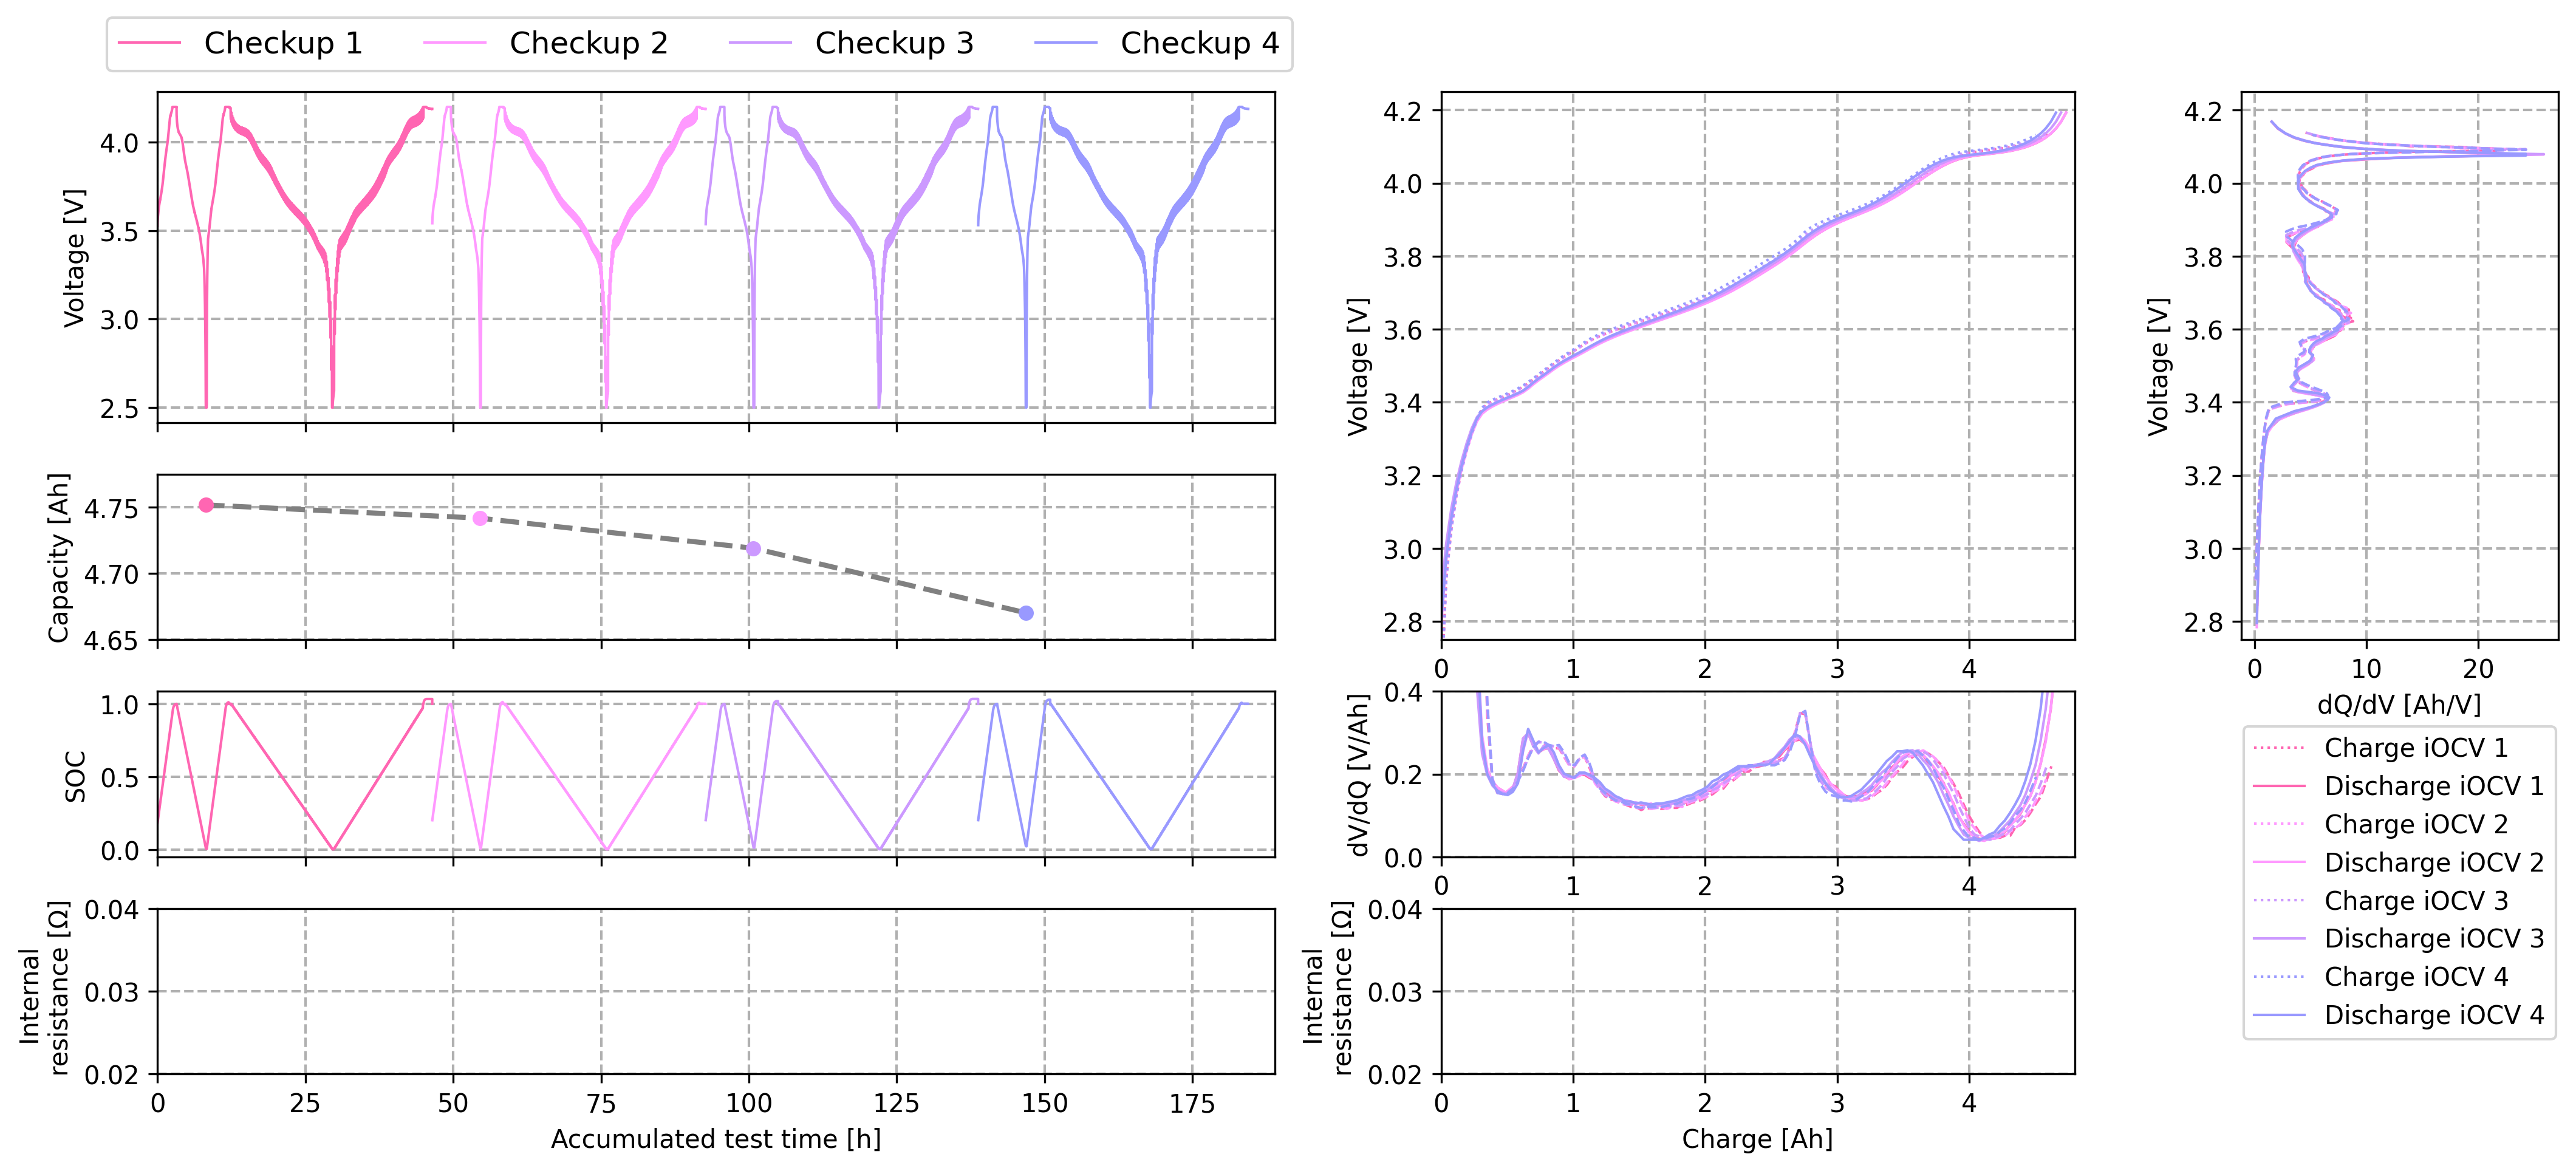

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# =========================================================
# Einstellungen
# =========================================================
dpi = 300
lw_left = 1
lw_right = 1
alpha = 1

# Falls du df_merged später noch vollständig brauchst:
df_plot = df_merged.copy()
df_plot = df_plot[df_plot["TestIndex"] >= 0]

# Separate Charge and Discharge blocks
charge_blocks = [df for df in ocv_data if df["iOCV_type"].iloc[0] == "Charge"]
discharge_blocks = [df for df in ocv_data if df["iOCV_type"].iloc[0] == "Discharge"]

# =========================================================
# Gemeinsame Figure + gemeinsames Raster
# =========================================================
fig = plt.figure(figsize=(17, 7), dpi=dpi)

gs = GridSpec(
    4,
    4,
    figure=fig,
    height_ratios=[4, 2, 2, 2],
    width_ratios=[4, 2, 4, 2],
    hspace=0.25,
    wspace=0.35,
)

# ---------------------------------------------------------
# Linke Seite: 4 übereinander
# ---------------------------------------------------------
axL0 = fig.add_subplot(gs[0, 0:2])  # Voltage
axL1 = fig.add_subplot(gs[1, 0:2], sharex=axL0)  # Capacity
axL2 = fig.add_subplot(gs[2, 0:2], sharex=axL0)  # SOC
axL3 = fig.add_subplot(gs[3, 0:2], sharex=axL0)  # Internal Resistance

# ---------------------------------------------------------
# Rechte Seite: auf gleiches Raster gemappt
# ---------------------------------------------------------
axR0 = fig.add_subplot(gs[0:2, 2])  # OCV (über 2 Zeilen)
axR1 = fig.add_subplot(gs[2, 2])  # DVA
axR2 = fig.add_subplot(gs[0:2, 3])  # ICA (über 2 Zeilen)
axR3 = fig.add_subplot(gs[3, 2])  # Internal Resistance vs SOC
axRleg = fig.add_subplot(gs[2:4, 3])  # Legende

# =========================================================
# Linker Plotblock
# =========================================================
mask_cap = ~np.isnan(df_plot["Capacity[Ah]"])
axL1.plot(
    df_plot["Test_Time[s]"][mask_cap] / 3600,
    df_plot["Capacity[Ah]"][mask_cap],
    marker=".",
    markersize=0,
    linestyle="--",
    color="gray",
    lw=2,
)

for i, test_index in enumerate(df_plot["TestIndex"].unique()):
    if test_index >= 0:
        mask = df_plot["TestIndex"] == test_index

        axL0.plot(
            df_plot["Test_Time[s]"][mask] / 3600,
            df_plot["Voltage[V]"][mask],
            label=f"Checkup {int(test_index) + 1}",
            lw=lw_left,
            color=colors[i],
        )

        axL1.plot(
            df_plot["Test_Time[s]"][mask] / 3600,
            df_plot["Capacity[Ah]"][mask],
            marker=".",
            markersize=10,
            lw=0,
            color=colors[i],
        )

        axL2.plot(
            df_plot["Test_Time[s]"][mask] / 3600,
            df_plot["SOC"][mask],
            lw=lw_left,
            color=colors[i],
        )

        axL3.plot(
            df_plot["Test_Time[s]"][mask] / 3600,
            df_plot["InternalResistance[ohm]"][mask],
            lw=0,
            marker=".",
            markersize=3,
            color=colors[i],
        )

# Formatierung links
for ax in [axL0, axL1, axL2, axL3]:
    ax.grid(True, which="both", linestyle="--", linewidth=1)

xmax_h = 680000 / 3600

axL0.set_xlim(0, xmax_h)
axL0.set_ylabel("Voltage [V]")

axL1.set_xlim(0, xmax_h)
axL1.set_ylabel("Capacity [Ah]")
axL1.set_ylim(4.65, 4.775)

axL2.set_xlim(0, xmax_h)
axL2.set_ylabel("SOC")

axL3.set_xlim(0, xmax_h)
axL3.set_xlabel("Accumulated test time [h]")
axL3.set_ylabel("Internal \n resistance [Ω]")
axL3.set_ylim(0.02, 0.04)

# obere x-Ticks ausblenden
plt.setp(axL0.get_xticklabels(), visible=False)
plt.setp(axL1.get_xticklabels(), visible=False)
plt.setp(axL2.get_xticklabels(), visible=False)

# Gemeinsame Legende links oben
handles_left, labels_left = axL0.get_legend_handles_labels()
fig.legend(
    handles_left,
    labels_left,
    loc="upper center",
    ncol=min(4, len(labels_left)),
    bbox_to_anchor=(0.30, 0.95),
    fontsize="large",
    frameon=True,
)

# =========================================================
# Rechter Plotblock
# =========================================================
for i, df in enumerate(charge_blocks):
    # Charge
    Q = df["AbsoluteChargeThroughput[Ah]"] - df["AbsoluteChargeThroughput[Ah]"].iloc[0]
    label_charge = f"Charge iOCV {i + 1}"

    axR0.plot(
        Q,
        df["Voltage[V]"],
        label=label_charge,
        linewidth=lw_right,
        linestyle=":",
        alpha=alpha,
        color=colors[i],
    )

    dva = df["Voltage[V]"].diff() / Q.diff()
    ica = 1 / dva

    axR1.plot(
        Q,
        dva,
        linewidth=lw_right,
        linestyle="--",
        alpha=alpha,
        color=colors[i],
    )

    axR2.plot(
        ica,
        df["Voltage[V]"],
        linewidth=lw_right,
        linestyle="--",
        alpha=alpha,
        color=colors[i],
    )

    # Discharge
    df_d = discharge_blocks[i]
    label_discharge = f"Discharge iOCV {i + 1}"

    Qd = df_d["AbsoluteChargeThroughput[Ah]"].iloc[0] - df_d["AbsoluteChargeThroughput[Ah]"]
    Qd = Qd - np.nanmin(Qd)

    axR0.plot(
        Qd,
        df_d["Voltage[V]"],
        label=label_discharge,
        linewidth=lw_right,
        linestyle="-",
        alpha=alpha,
        color=colors[i],
    )

    dva_d = df_d["Voltage[V]"].diff() / Qd.diff()
    ica_d = 1 / dva_d

    axR1.plot(
        Qd,
        dva_d,
        linewidth=lw_right,
        linestyle="-",
        alpha=alpha,
        color=colors[i],
    )

    axR2.plot(
        ica_d,
        df_d["Voltage[V]"],
        linewidth=lw_right,
        linestyle="-",
        alpha=alpha,
        color=colors[i],
    )

# Rechter unterer IR-Plot
for i, test_index in enumerate(df_plot["TestIndex"].unique()):
    if test_index >= 0:
        mask = df_plot["TestIndex"] == test_index

        axR3.plot(
            df_plot.loc[mask, "SOC"].iloc[::4] * 4.7,
            df_plot.loc[mask, "InternalResistance[ohm]"].iloc[::4],
            linewidth=lw_right,
            linestyle="",
            marker=".",
            markersize=3,
            alpha=alpha,
            color=colors[i],
        )

# Formatierung rechts
for ax in [axR0, axR1, axR2, axR3]:
    ax.grid(True, which="both", linestyle="--", linewidth=1)

axR0.set_xlabel("Charge [Ah]")
axR0.set_ylabel("Voltage [V]")
axR0.set_ylim(2.75, 4.25)
axR0.set_xlim(0, 4.8)

axR1.set_xlabel("Charge [Ah]")
axR1.set_ylabel("dV/dQ [V/Ah]")
axR1.set_ylim(0, 0.4)
axR1.set_xlim(0, 4.8)

axR2.set_xlabel("dQ/dV [Ah/V]")
axR2.set_ylabel("Voltage [V]")
axR2.set_ylim(2.75, 4.25)
# axR2.set_xlim(0, 4.8)

axR3.set_xlabel("Charge [Ah]")
axR3.set_ylabel("Internal \n resistance [Ω]")
axR3.set_ylim(0.02, 0.04)
axR3.set_xlim(0, 4.8)

# Legende rechts in freie Fläche
handles_right, labels_right = axR0.get_legend_handles_labels()
axRleg.legend(
    handles_right,
    labels_right,
    loc="center",
    frameon=True,
    ncol=1,
)
axRleg.axis("off")

# =========================================================
# Feinschliff
# =========================================================
fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# Export

Export data frame to Parquet file.

In [10]:
# eet.write(df, output_path="./parquet", output_file_name="Test_Output")